# FIFA World Cup 2026 — Top Scorers

Phase-2 report. Reads `player_season_stat` (seeded by `players_ingest.py`) and
shows the tournament scoring leaders: a detail table plus a goal-involvement
(goals + assists) chart. Refresh the underlying data with
`python src/players_ingest.py --mode both`.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))

%matplotlib inline
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import HTML, display

import report_players
from config import DB_PATH

display(HTML("""
<style>
table.dataframe { border-collapse: collapse !important; border: 2px solid rgba(0,0,0,0.2) !important; }
table.dataframe td, table.dataframe th { border: 1.5px solid rgba(0,0,0,0.15) !important; }
table.dataframe thead th { background-color: #f0f0f0 !important; font-weight: bold !important; }
</style>
"""))

conn = sqlite3.connect(DB_PATH)
print("Database:", DB_PATH)

Database: /Users/marcalexander/projects/ai_orchestrator_claude/world_cup_soccer_2026/data/worldcup.db


## Scoring leaders (top 20)

In [2]:
display(report_players.load_top_scorers(conn, limit=20))

,rank,player,team,mp,min,g,a,rating,g/90
0,1,Folarin Balogun,USA,1,72,2,0,9.0,2.50
1,2,Kai Havertz,GER,1,90,2,0,8.3,2.00
2,3,Elijah Just,NZL,1,90,2,0,9.0,2.00
3,4,Yasin Ayari,SWE,1,90,2,0,8.6,2.00
4,5,Deniz Undav,GER,1,26,1,2,8.3,3.46
5,6,Alexander Isak,SWE,1,89,1,2,8.9,1.01
6,7,Nathaniel Brown,GER,1,73,1,1,8.0,1.23
7,8,Hwang In-Beom,KOR,1,84,1,1,8.9,1.07
8,9,Ramin Rezaeian,IRN,1,90,1,1,9.3,1.00
9,10,Viktor Gyökeres,SWE,1,90,1,1,8.2,1.00


## Goal involvements (goals + assists)

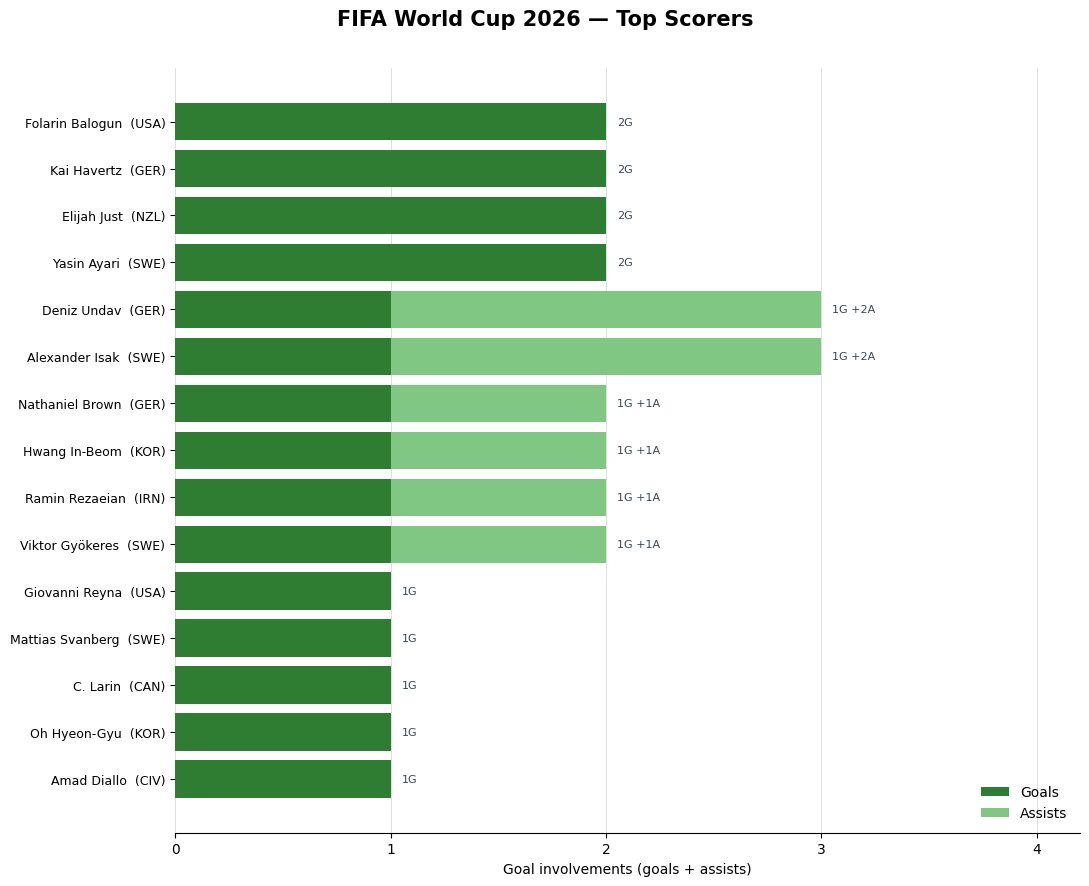

In [3]:
# Build once, show once (plt.show() avoids the inline + bare-fig double render).
fig = report_players.build_top_scorers_figure(conn, top_n=15)
plt.show()